--- Model Parameters ---
Learned Slope (w): 3.6326
Learned Bias (b): 11.3100

--- Regression Metrics Summary ---
                        Metric  Value
     Mean Absolute Error (MAE) 2.0796
      Mean Squared Error (MSE) 6.6556
Root Mean Squared Error (RMSE) 2.5798
          R-squared (R² Score) 0.9304
            Adjusted R-squared 0.9300


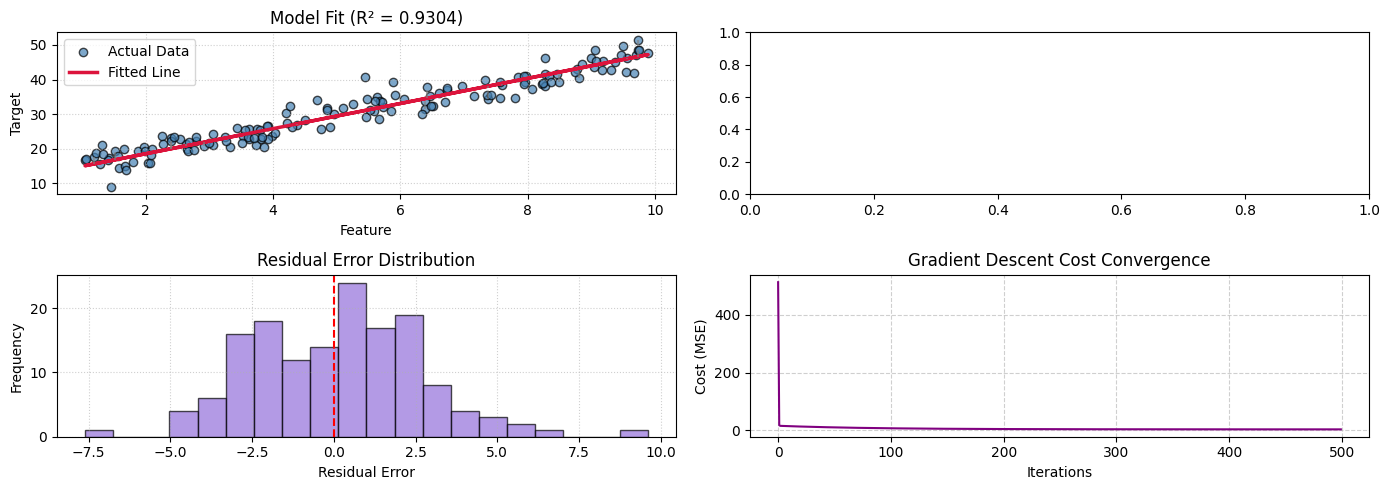

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

n = 150
x = np.random.uniform(1, 10, size=(n, 1))
noise = np.random.normal(0, 2.5, size=(n, 1))
y = 3.5 * x + 12.0 + noise

df = pd.DataFrame({
    "Feature": x.flatten(),
    "Target": y.flatten()
})


class LR:

    def __init__(self, lr=0.03, it=500):
        self.lr = lr
        self.it = it
        self.w = None
        self.b = None
        self.cost = []

    def fit(self, x, y):

        m, nf = x.shape

        self.w = np.zeros((nf, 1))
        self.b = 0.0
        self.cost = []

        for _ in range(self.it):

            yp = np.dot(x, self.w) + self.b

            c = (1 / (2 * m)) * np.sum((yp - y) ** 2)
            self.cost.append(c)

            dw = (1 / m) * np.dot(x.T, (yp - y))
            db = (1 / m) * np.sum(yp - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, x):
        return np.dot(x, self.w) + self.b

    def mse(self, yt, yp):
        return np.mean((yt - yp) ** 2)

    def rmse(self, yt, yp):
        return np.sqrt(self.mse(yt, yp))

    def mae(self, yt, yp):
        return np.mean(np.abs(yt - yp))

    def r2(self, yt, yp):

        ssr = np.sum((yt - yp) ** 2)
        sst = np.sum((yt - np.mean(yt)) ** 2)

        return 1 - (ssr / sst)

    def adj_r2(self, yt, yp, nf):

        n = len(yt)
        r2 = self.r2(yt, yp)

        return 1 - ((1 - r2) * (n - 1) / (n - nf - 1))


x = df[["Feature"]].values
y = df[["Target"]].values

model = LR(lr=0.03, it=500)
model.fit(x, y)

yp = model.predict(x)

mse = model.mse(y, yp)
rmse = model.rmse(y, yp)
mae = model.mae(y, yp)
r2 = model.r2(y, yp)
ar2 = model.adj_r2(y, yp, x.shape[1])


met = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R-squared (R² Score)",
        "Adjusted R-squared"
    ],

    "Value": [
        f"{mae:.4f}",
        f"{mse:.4f}",
        f"{rmse:.4f}",
        f"{r2:.4f}",
        f"{ar2:.4f}"
    ]
})


print("--- Model Parameters ---")
print(f"Learned Slope (w): {model.w[0][0]:.4f}")
print(f"Learned Bias (b): {model.b:.4f}\n")

print("--- Regression Metrics Summary ---")
print(met.to_string(index=False))


fig, ax = plt.subplots(2, 2, figsize=(14, 5))


ax[0][0].scatter(
    df["Feature"],
    df["Target"],
    color="steelblue",
    alpha=0.7,
    edgecolor="k",
    label="Actual Data"
)

ax[0][0].plot(
    df["Feature"],
    yp,
    color="crimson",
    linewidth=2.5,
    label="Fitted Line"
)


for i in range(15):

    ax[0][0].vlines(
        x=df["Feature"].iloc[i],
        ymin=min(y[i][0], yp[i][0]),
        ymax=max(y[i][0], yp[i][0]),
        colors="gray",
        linestyle="--",
        alpha=0.6
    )


ax[0][0].set_title(f"Model Fit (R² = {r2:.4f})")
ax[0][0].set_xlabel("Feature")
ax[0][0].set_ylabel("Target")
ax[0][0].legend()
ax[0][0].grid(True, linestyle=":", alpha=0.6)


res = y - yp

ax[1][0].hist(
    res,
    bins=20,
    color="mediumpurple",
    edgecolor="black",
    alpha=0.7
)

ax[1][0].axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

ax[1][0].set_title("Residual Error Distribution")
ax[1][0].set_xlabel("Residual Error")
ax[1][0].set_ylabel("Frequency")
ax[1][0].grid(True, linestyle=":", alpha=0.6)


ax[1][1].plot(
    range(len(model.cost)),
    model.cost,
    color="purple"
)

ax[1][1].set_xlabel("Iterations")
ax[1][1].set_ylabel("Cost (MSE)")
ax[1][1].set_title("Gradient Descent Cost Convergence")
ax[1][1].grid(True, linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()

--- Parameters Calculated via Normal Equation ---
Calculated Slope (w): 3.5486
Calculated Bias (b): 11.8618

--- Regression Metrics Summary ---
                        Metric  Value
     Mean Absolute Error (MAE) 2.0548
      Mean Squared Error (MSE) 6.5935
Root Mean Squared Error (RMSE) 2.5678
          R-squared (R² Score) 0.9311
            Adjusted R-squared 0.9306


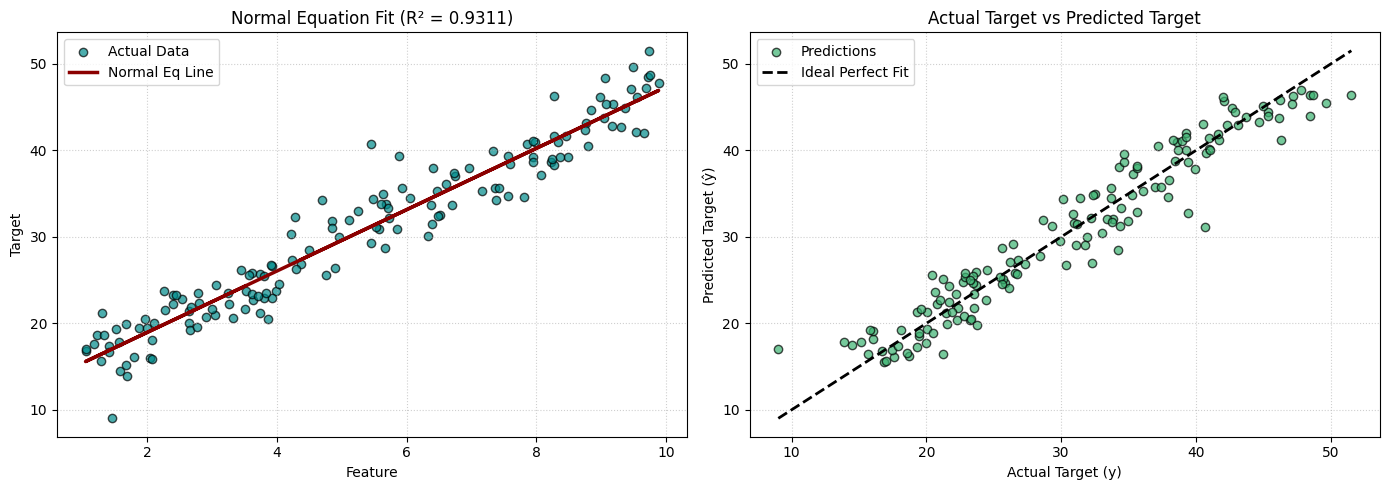

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

n = 150
x = np.random.uniform(1, 10, size=(n, 1))
noise = np.random.normal(0, 2.5, size=(n, 1))
y = 3.5 * x + 12.0 + noise

df = pd.DataFrame({
    "Feature": x.flatten(),
    "Target": y.flatten()
})


class LR:

    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, x, y):

        m = x.shape[0]

        xb = np.hstack([
            np.ones((m, 1)),
            x
        ])

        xt = xb.T

        theta = np.linalg.inv(
            xt @ xb
        ) @ xt @ y

        self.b = theta[0][0]
        self.w = theta[1:]

    def predict(self, x):
        return x @ self.w + self.b

    def mse(self, yt, yp):
        return np.mean((yt - yp) ** 2)

    def rmse(self, yt, yp):
        return np.sqrt(self.mse(yt, yp))

    def mae(self, yt, yp):
        return np.mean(np.abs(yt - yp))

    def r2(self, yt, yp):

        ssr = np.sum((yt - yp) ** 2)
        sst = np.sum((yt - np.mean(yt)) ** 2)

        return 1 - (ssr / sst)

    def adj_r2(self, yt, yp, nf):

        n = len(yt)
        r2 = self.r2(yt, yp)

        return 1 - ((1 - r2) * (n - 1) / (n - nf - 1))


x = df[["Feature"]].values
y = df[["Target"]].values

model = LR()

model.fit(x, y)

yp = model.predict(x)


mae = model.mae(y, yp)
mse = model.mse(y, yp)
rmse = model.rmse(y, yp)
r2 = model.r2(y, yp)
ar2 = model.adj_r2(y, yp, x.shape[1])


met = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R-squared (R² Score)",
        "Adjusted R-squared"
    ],

    "Value": [
        f"{mae:.4f}",
        f"{mse:.4f}",
        f"{rmse:.4f}",
        f"{r2:.4f}",
        f"{ar2:.4f}"
    ]
})


print("--- Parameters Calculated via Normal Equation ---")
print(f"Calculated Slope (w): {model.w[0][0]:.4f}")
print(f"Calculated Bias (b): {model.b:.4f}\n")

print("--- Regression Metrics Summary ---")
print(met.to_string(index=False))


fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].scatter(
    df["Feature"],
    df["Target"],
    color="darkcyan",
    alpha=0.7,
    edgecolor="k",
    label="Actual Data"
)

ax[0].plot(
    df["Feature"],
    yp,
    color="darkred",
    linewidth=2.5,
    label="Normal Eq Line"
)

ax[0].set_title(
    f"Normal Equation Fit (R² = {r2:.4f})"
)

ax[0].set_xlabel("Feature")
ax[0].set_ylabel("Target")
ax[0].legend()
ax[0].grid(True, linestyle=":", alpha=0.6)


ax[1].scatter(
    y,
    yp,
    color="mediumseagreen",
    alpha=0.7,
    edgecolor="k",
    label="Predictions"
)

ax[1].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "k--",
    lw=2,
    label="Ideal Perfect Fit"
)

ax[1].set_title(
    "Actual Target vs Predicted Target"
)

ax[1].set_xlabel("Actual Target (y)")
ax[1].set_ylabel("Predicted Target (ŷ)")
ax[1].legend()
ax[1].grid(True, linestyle=":", alpha=0.6)


plt.tight_layout()
plt.show()